In [1]:
%cd /content

!mkdir -p ml-assessment-shantanu-rastogi/part_a
!mkdir -p ml-assessment-shantanu-rastogi/data

%cd ml-assessment-shantanu-rastogi/part_a

/content
/content/ml-assessment-shantanu-rastogi/part_a


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/q3_retail_promotions.csv')

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [4]:
df['year'] = df['transaction_date'].dt.year

df['month'] = df['transaction_date'].dt.month

df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

In [5]:
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

New temporal features were created from transaction_date:

- year
- month
- day_of_week
- is_month_end

These features may help capture seasonal and time-based patterns affecting items sold.

In [6]:
df = df.sort_values('transaction_date')

In [7]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]

In [8]:
print(train_df.shape)

print(test_df.shape)

(960, 13)
(240, 13)


### Temporal Train-Test Split

A time-based split was used:

- First 80% records → Training set
- Most recent 20% records → Test set

A random split is inappropriate because this is time-ordered data.

Using random splitting could cause data leakage by allowing future information to influence training.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [10]:
X_train = train_df.drop(
    ['items_sold','transaction_date'],
    axis=1
)

y_train = train_df['items_sold']

X_test = test_df.drop(
    ['items_sold','transaction_date'],
    axis=1
)

y_test = test_df['items_sold']

In [11]:
categorical_features = [
    'promotion_type',
    'location_type',
    'store_size'
]

In [12]:
numerical_features = [
    'store_id',
    'is_weekend',
    'is_festival',
    'competition_density',
    'year',
    'month',
    'day_of_week',
    'is_month_end'
]

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(drop='first'),
            categorical_features
        ),
        (
            'num',
            StandardScaler(),
            numerical_features
        )
    ]
)

### Preprocessing Pipeline

A preprocessing pipeline was created using ColumnTransformer.

It applies:

- One-hot encoding to categorical features
- Standard scaling to numerical features

This ensures proper preprocessing is applied consistently to both training and test data.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [15]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

In [16]:
lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

print("Linear Regression RMSE:", lr_rmse)

print("Linear Regression MAE:", lr_mae)

Linear Regression RMSE: 27.12145116489062
Linear Regression MAE: 21.052926674588388


In [17]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

In [18]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

print("Random Forest RMSE:", rf_rmse)

print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 31.660007317329118
Random Forest MAE: 24.87391666666667


### Model Comparison

Linear Regression outperformed Random Forest based on both evaluation metrics:

- Lower RMSE
- Lower MAE

Therefore, Linear Regression is the preferred model for this problem.

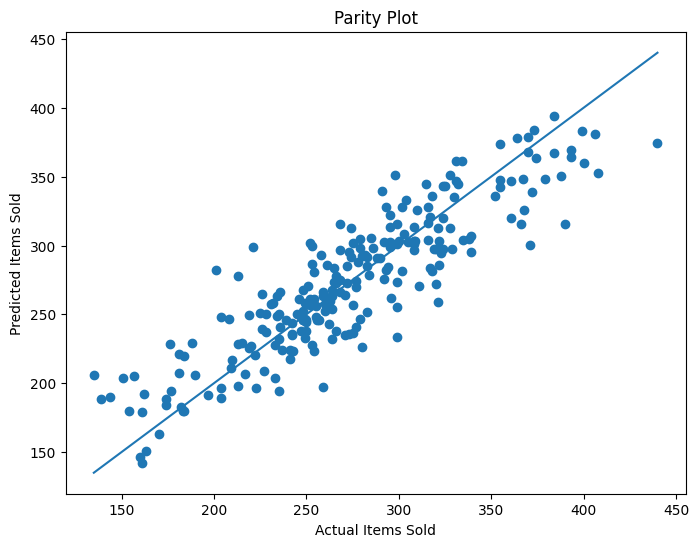

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel('Actual Items Sold')

plt.ylabel('Predicted Items Sold')

plt.title('Parity Plot')

plt.show()

In [20]:
feature_names = (
    rf_pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    rf_pipeline.named_steps['model']
    .feature_importances_
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(5))

                     Feature  Importance
7      cat__store_size_small    0.183954
10          num__is_festival    0.174477
5   cat__location_type_urban    0.140498
14          num__day_of_week    0.090612
9            num__is_weekend    0.063547


### Feature Importance

The most influential features in the Random Forest model were:

- store_size_small
- is_festival
- location_type_urban
- day_of_week
- is_weekend

This suggests both store characteristics and calendar-related factors strongly influence items sold.

### Parity Plot Interpretation

The parity plot shows predicted values generally align with actual items sold.

Most points lie reasonably close to the diagonal reference line, suggesting the Linear Regression model captures the relationship in the data reasonably well.